# **Churn Prediction EDA**

**Decscription**

**Objective**

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Initial EDA

In [41]:
# Import sample data
df = pd.read_csv('sample.csv')
df.head()

,customer_id,age,tenure_months,monthly_spend,num_support_tickets,region,plan_type,payment_method,churned
0,C0001,62.0,15.0,51.28,3,East,Basic,credit_card,0
1,C0002,27.0,76.0,122.83,1,East,Enterprise,credit_card,1
2,C0003,67.0,84.0,127.73,9,South,Enterprise,credit_card,0
3,C0004,31.0,28.0,89.66,6,West,Premium,bank_transfer,0
4,C0005,68.0,59.0,57.30,6,West,Basic,paypal,0


In [42]:
df[['age', 'tenure_months', 'monthly_spend', 'num_support_tickets']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,2414.0,44.718310,13.428271,22.00,33.0000,44.00,56.0000,68.00
tenure_months,2422.0,48.650702,27.890996,1.00,24.0000,49.00,73.0000,96.00
monthly_spend,2500.0,89.778752,33.491759,32.02,63.4875,88.95,112.9125,147.98
num_support_tickets,2500.0,4.984800,3.193846,0.00,2.0000,5.00,8.0000,10.00


In [43]:
print(f'Region uniques: {df.region.unique()}')
print(f'Payment method uniques: {df.payment_method.unique()}')
print(f'Plan type uniques: {df.plan_type.unique()}')

Region uniques: ['East' 'South' 'West' 'Midwest']
Payment method uniques: ['credit_card' 'bank_transfer' 'paypal']
Plan type uniques: ['Basic' 'Enterprise' 'Premium' 'Standard']


**Observations:**

- **customer_id** will have no impact on prediction, it can be dropped
- **age, tenure_months, monthly_spend, num_support_tickets** are descrete numberical and thus should be normalized, I will use min-max scaling.
- **region, and payment_method** are categorical and have a small number of uniques without an obvious hierarchy, so I will use one-hot-encoding.
- **plan_type** is categorical and does have an obvious hierarchy, so I will use ordinal encoding.

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          2500 non-null   object 
 1   age                  2414 non-null   float64
 2   tenure_months        2422 non-null   float64
 3   monthly_spend        2500 non-null   float64
 4   num_support_tickets  2500 non-null   int64  
 5   region               2500 non-null   object 
 6   plan_type            2500 non-null   object 
 7   payment_method       2500 non-null   object 
 8   churned              2500 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 175.9+ KB


**Observations**
- Objects seem to just be strings
- There are some missing values, but not enough to affect the training if I drop them, so I will just drop them this time.

##

## Import cleaned sample

In [46]:
# smaple.csv cleaned using csv-pipeline
df_cleaned = pd.read_csv('cleaned_sample.csv')
df_cleaned.head()

,customer_id,age,tenure_months,monthly_spend,num_support_tickets,plan_type,churned,region_East,region_Midwest,region_South,region_West,payment_bank_transfer,payment_credit_card,payment_paypal
0,C0001,0.870,0.147,0.166,0.3,0,0,True,False,False,False,False,True,False
1,C0002,0.109,0.789,0.783,0.1,3,1,True,False,False,False,False,True,False
2,C0003,0.978,0.874,0.825,0.9,3,0,False,False,True,False,False,True,False
3,C0004,0.196,0.284,0.497,0.6,2,0,False,False,False,True,True,False,False
4,C0005,1.000,0.611,0.218,0.6,0,0,False,False,False,True,False,False,True


In [47]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            2340 non-null   object 
 1   age                    2340 non-null   float64
 2   tenure_months          2340 non-null   float64
 3   monthly_spend          2340 non-null   float64
 4   num_support_tickets    2340 non-null   float64
 5   plan_type              2340 non-null   int64  
 6   churned                2340 non-null   int64  
 7   region_East            2340 non-null   bool   
 8   region_Midwest         2340 non-null   bool   
 9   region_South           2340 non-null   bool   
 10  region_West            2340 non-null   bool   
 11  payment_bank_transfer  2340 non-null   bool   
 12  payment_credit_card    2340 non-null   bool   
 13  payment_paypal         2340 non-null   bool   
dtypes: bool(7), float64(4), int64(2), object(1)
memory usage

In [48]:
# Last thing is to drop the customer_id col
df_final = df_cleaned.drop('customer_id', axis=1)
df_final.head()

,age,tenure_months,monthly_spend,num_support_tickets,plan_type,churned,region_East,region_Midwest,region_South,region_West,payment_bank_transfer,payment_credit_card,payment_paypal
0,0.870,0.147,0.166,0.3,0,0,True,False,False,False,False,True,False
1,0.109,0.789,0.783,0.1,3,1,True,False,False,False,False,True,False
2,0.978,0.874,0.825,0.9,3,0,False,False,True,False,False,True,False
3,0.196,0.284,0.497,0.6,2,0,False,False,False,True,True,False,False
4,1.000,0.611,0.218,0.6,0,0,False,False,False,True,False,False,True


### Perpare training data

In [49]:
# Determine X and y
X = df_final.drop('churned', axis=1)
y = df_final.churned

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Determine the best max_depth for the random forest

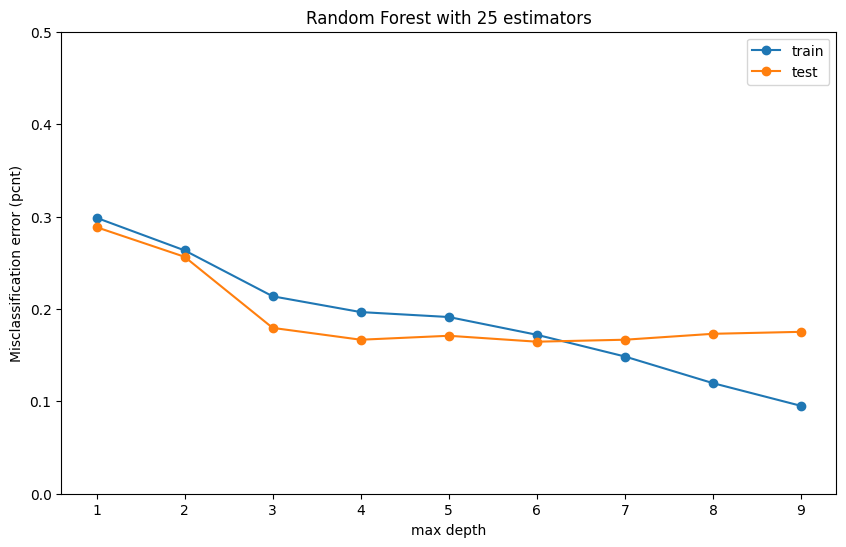

In [52]:
train_scores = []
test_scores = []

# Looking 1 - 10
for depth in range(1, 10):

    # Fit classifier to the current depth
    clf = RandomForestClassifier(random_state=0, criterion='entropy', max_depth=depth, n_estimators=25)
    clf = clf.fit(X_train, y_train)

    # Append classifier score
    train_scores.append(1 - clf.score(X_train, y_train))
    test_scores.append(1 - clf.score(X_test, y_test))

# Plot the scores
plt.plot(range(1, 10), train_scores, '-o', label="train")
plt.plot(range(1, 10), test_scores, '-o', label="test")
plt.legend(loc='upper right')
plt.xlabel('max depth')
plt.ylim(0, 0.5)
plt.ylabel('Misclassification error (pcnt)')
plt.title(f"Random Forest with 25 estimators")

# Setup figure
fig = plt.gcf()
fig.set_size_inches(10, 6)

# Show plot
plt.show()

**Observations**

- I'm going to go with a **max_depth of 6** because the test dataset closely matches the train dataset at its lowest misclassification error percentage.
- The model is doing a pretty good job of classifing because the training set error rate is never constant, meaning it did not over fit the data.

### Final classifier model

In [54]:
# Final classifier training
clf_final = RandomForestClassifier(random_state=0, criterion='entropy', max_depth=6, n_estimators=25)
clf_final = clf_final.fit(X_train, y_train)

### Determine the feature importance

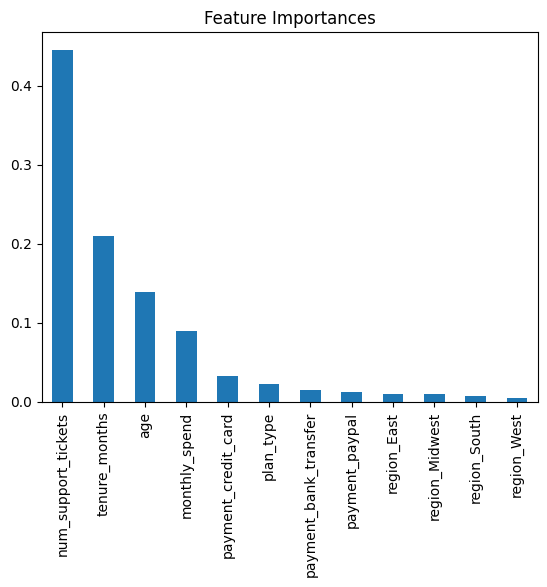

In [70]:
importances = pd.Series(
    clf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.plot(kind="bar", title="Feature Importances");

## Random prediction

In [ ]:
# Run a randomly generated customer prediction
customer = pd.DataFrame([{
    "age":                  36,
    "tenure_months":        12,
    "monthly_spend":        20,
    "num_support_tickets":  1,
    "plan_type":            0,
    "region_East":          False,
    "region_Midwest":       False,
    "region_South":         True,
    "region_West":          False,
    "payment_bank_transfer":False,
    "payment_credit_card":  True,
    "payment_paypal":       False
}])

prediction = clf_final.predict(customer)
confidence = clf_final.predict_proba(customer)

print(f"Prediction:  {prediction[0]}  ({'Churn' if prediction[0] == 1 else 'No Churn'})")
print(f"Confidence:  {confidence[0][1]}")

Prediction:  1  (Churn)
Confidence:  0.5702580580368077
